**TYPES OF DATA AND VARIABLES**

In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
np.random.seed(42)
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
#Numerical Data VS Categorical Data
print(df.dtypes)
numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [3]:
#Statistic Type
print('Mean total_bill:', round(df['total_bill'].mean(), 2))
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


**MEASURES OF CENTRAL TENDENCY**

In [4]:
#Mean, Median, Mode
col = df['total_bill']
print('Mean   :', round(col.mean(), 2))
print('Median :', round(col.median(), 2))
print('Mode   :', round(col.mode()[0], 2))

Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


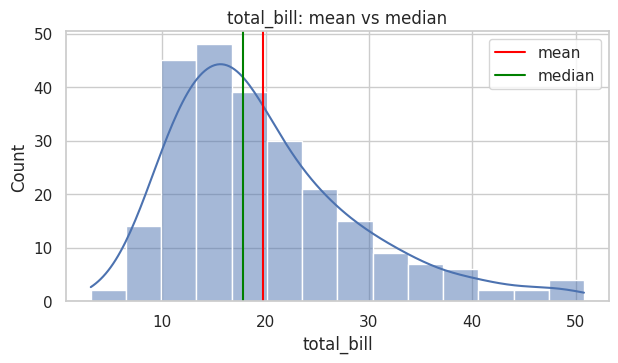

In [5]:
#Skew
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')
plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

In [6]:
#Lab Exercise: Mean, Median, Mode
tip = df['tip']
mean_tip = tip.mean()
median_tip = tip.median()
mode_tip = tip.mode()[0]
print(f"Mean: {mean_tip:.2f}")
print(f"Median: {median_tip:.2f}")
print(f"Mode: {mode_tip:.2f}")

Mean: 3.00
Median: 2.90
Mode: 2.00


In [7]:
#Lab Exercise: Mean > Median
is_mean_greater = mean_tip > median_tip
print(f"Is mean > median? {is_mean_greater}")

Is mean > median? True


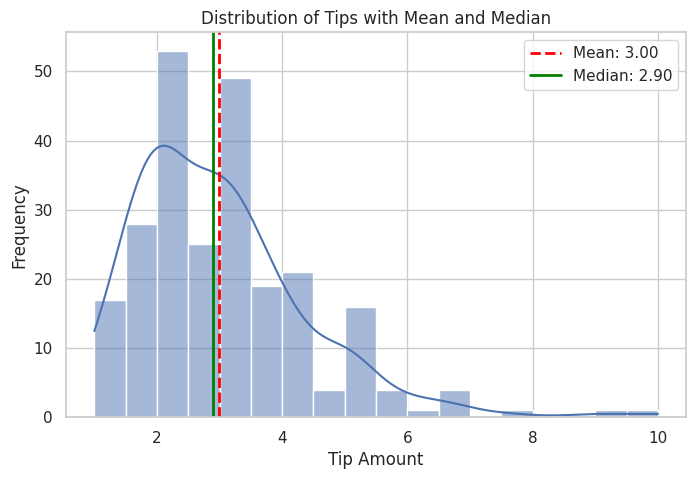

In [8]:
#Lab Exercise: Histogram
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(tip, kde=True)
plt.axvline(
    mean_tip,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_tip:.2f}",
)
plt.axvline(
    median_tip,
    color="green",
    linestyle="-",
    linewidth=2,
    label=f"Median: {median_tip:.2f}",
)
plt.title("Distribution of Tips with Mean and Median")
plt.xlabel("Tip Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

**MEASURES OF SPEED DISPERSION**

In [9]:
#Range, Variance, Standard Deviation
col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))
print('Var   :', round(col.var(), 2))
print('Std   :', round(col.std(), 2))

Range : 47.74
Var   : 79.25
Std   : 8.9


In [10]:
#Quartiles And The Inter Quartile Range(IQR)
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [11]:
#Lab Exercise: Range, Variance, Standard Deviation
range_tip = tip.max() - tip.min()
variance_tip = tip.var()
std_tip = tip.std()
print(f"Range: {range_tip:.2f}")
print(f"Variance: {variance_tip:.2f}")
print(f"Standard Deviation: {std_tip:.2f}")

Range: 9.00
Variance: 1.91
Standard Deviation: 1.38


In [12]:
#Lab Exercise: Q1, Q3, IQR
q1 = tip.quantile(0.25)
q3 = tip.quantile(0.75)
iqr = q3 - q1
print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")

Q1: 2.00
Q3: 3.56
IQR: 1.56


**Question: Most Robust Measure Of Spread = Interquartile Range (IQR)**

Unlike range, variance, and standard deviation, the IQR is resistant to extreme values and outliers because it only focuses on the middle 50% of the data.

In [13]:
#Five Number Summary
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)
print('\nSkewness:', round(col.skew(), 3))

min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


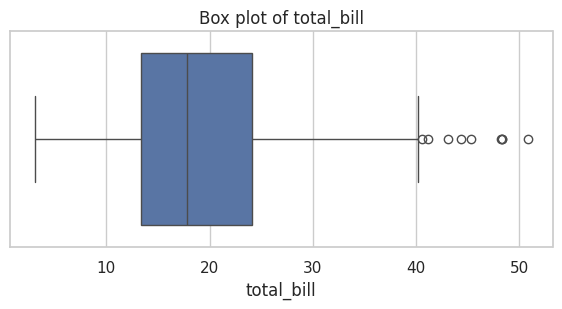

In [14]:
#Box Plot
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()

In [15]:
#Lab Exercise: Five Number Summary
min_val = tip.min()
q1 = tip.quantile(0.25)
median_val = tip.median()
q3 = tip.quantile(0.75)
max_val = tip.max()
print("Five-Number Summary:")
print(f"Min: {min_val:.2f}")
print(f"Q1: {q1:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Q3: {q3:.2f}")
print(f"Max: {max_val:.2f}")

Five-Number Summary:
Min: 1.00
Q1: 2.00
Median: 2.90
Q3: 3.56
Max: 10.00


In [16]:
#Lab Exercise: Skewness
skewness = tip.skew()
print(f"\nSkewness: {skewness:.2f}")
if skewness > 0:
    print("Interpretation: Right-skewed (positively skewed). The tail extends toward higher tip amounts on the right.")
elif skewness < 0:
    print("Interpretation: Left-skewed (negatively skewed). The tail extends toward lower tip amounts on the left.")
else:
    print("Interpretation: Symmetric distribution.")


Skewness: 1.47
Interpretation: Right-skewed (positively skewed). The tail extends toward higher tip amounts on the right.


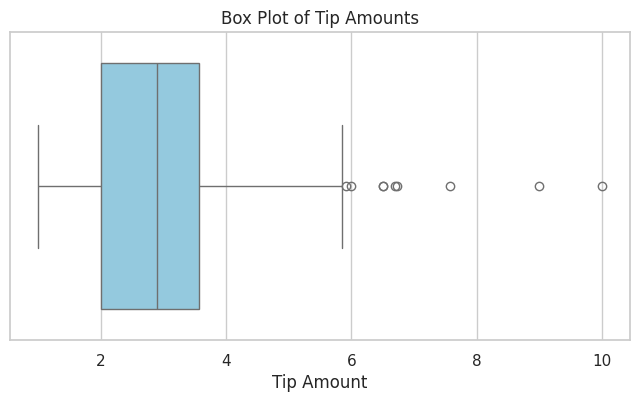

In [17]:
#Lab Exercise: Box Plot
plt.figure(figsize=(8, 4))
sns.boxplot(x=tip, color="skyblue")
plt.title("Box Plot of Tip Amounts")
plt.xlabel("Tip Amount")
plt.show()

**CORRELATION AND SUMMARIZING A DATASET**

In [18]:
#Correlation Matrix
corr = df.corr(numeric_only=True)
print(corr.round(2))
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


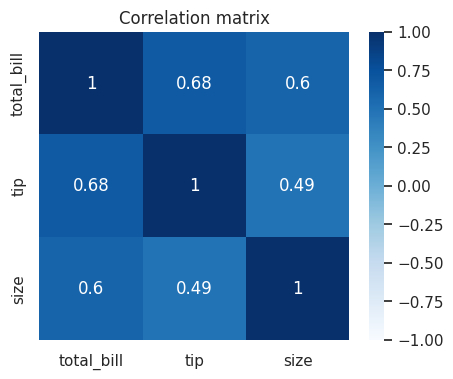

In [19]:
#Visualize Correlation Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()

In [20]:
#Summary
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [21]:
#Lab Exercise: Rounded Correlation Matrix
corr_matrix = df.corr(numeric_only=True).round(2)
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


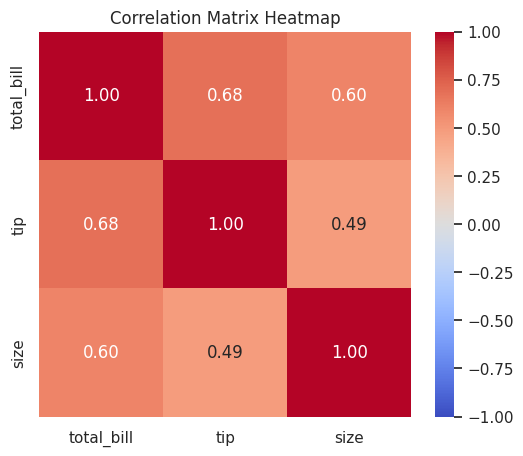

In [22]:
#Lab Exercise: Correlation Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [23]:
#Lab Exercise: Description And Insights
summary_stats = df.describe()
print("\nSummary Statistics:")
print(summary_stats)
# Insight 1: Strong positive linear relationship exists between 'total_bill' and 'tip', meaning higher bill amounts generally yield higher tip amounts.
# Insight 2: The average group size is around 2.5 people, with 50% of dining parties consisting of exactly 2 people (Q1 to median range).
# Insight 3: 'total_bill' and 'tip' both exhibit right-skewness, as their mean values (e.g., mean tip ~$3.00) are greater than their respective median values (e.g., median tip ~$2.90), with extreme maximum values pulling the mean up.


Summary Statistics:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000
